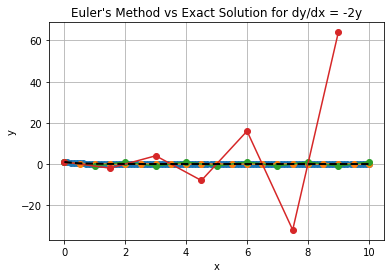

<Figure size 720x432 with 0 Axes>

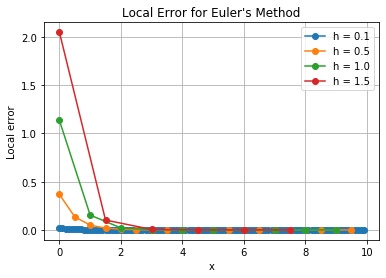

<Figure size 720x432 with 0 Axes>

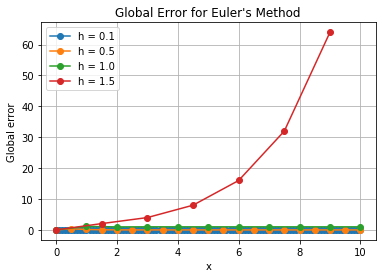

<Figure size 720x432 with 0 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y

# Exact solution
def y_exact(x):
    return np.exp(-2 * x)

# Euler's Method
def euler_method(h, x_start, x_end, y0):
    num_steps = int((x_end - x_start) / h)
    x_values = x_start + np.arange(num_steps + 1) * h
    y_values = np.zeros(num_steps + 1)

    y_values[0] = y0

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values

# Local Error
def compute_local_errors(x_values, h):
    local_errors = []

    for i in range(len(x_values) - 1):
        x_n = x_values[i]
        x_next = x_values[i + 1]

        y_true_n = y_exact(x_n)
        y_true_next = y_exact(x_next)

        # One Euler step, but starting from exact y_n
        y_euler_one_step = y_true_n + h * f(x_n, y_true_n)

        local_error = abs(y_true_next - y_euler_one_step)
        local_errors.append(local_error)
        
    return np.array(local_errors)

# Global Error
def compute_global_errors(x_values, y_values):
    y_true = y_exact(x_values)
    global_errors = np.abs(y_true - y_values)
    return global_errors

# Parameters
x_start = 0
x_end = 10
y0 = 1
h_values = [0.1, 0.5, 1.0, 1.5]

error_summary = []

#Plot Euler Approximations with Exact Solution
for h in h_values:
    x_values, y_values = euler_method(h, x_start, x_end, y0)
    plt.plot(x_values, y_values, marker='o', label=f"Euler h = {h}")

# Exact solution
x_exact = np.linspace(x_start, x_end, 500)
plt.plot(x_exact, y_exact(x_exact), 'k--', linewidth=2, label='Exact solution')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method vs Exact Solution for dy/dx = -2y")
plt.legend
plt.grid(True)
plt.figure(figsize=(10,6))
plt.show()

# Plot local error
for h in h_values:
    x_values, y_values = euler_method(h, x_start, x_end, y0)
    local_errors = compute_local_errors(x_values, h)

    # x_values[:-1]
    plt.plot(x_values[:-1], local_errors, marker='o', label=f"h = {h}")
    
plt.xlabel("x")
plt.ylabel("Local error")
plt.title("Local Error for Euler's Method")
plt.legend()
plt.grid(True)
plt.figure(figsize=(10, 6))
plt.show()

# Plot Global error
for h in h_values:
    x_values, y_values = euler_method(h, x_start, x_end, y0)
    global_errors = compute_global_errors(x_values, y_values)

    plt.plot(x_values, global_errors, marker='o', label=f"h = {h}")

    # Save total error summary
    total_global_error = np.sum(global_errors)
    max_global_error = np.max(global_errors)
    error_summary.append((h, total_global_error, max_global_error))

plt.xlabel("x")
plt.ylabel("Global error")
plt.title("Global Error for Euler's Method")
plt.legend()
plt.grid(True)
plt.figure(figsize=(10, 6))
plt.show()